In [1]:
# Installing Stuff
!pip install librosa --quiet
!pip install torchinfo --quiet
!pip install torchinfo seaborn --quiet

In [2]:
# Dependencies
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, multilabel_confusion_matrix

In [3]:
# Using Colab GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU Name   : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU found. Go to Runtime > Change runtime type > GPU")

Using device: cuda
GPU Name   : Tesla T4
GPU Memory : 15.6 GB


In [4]:
CLASSES = [
    "Asthma",               # index 0  — ICBHI + your filenames + lung dataset
    "Heart Failure",        # index 1  — your filenames + ICBHI
    "COPD",                 # index 2  — ICBHI + your filenames
    "Pneumonia",            # index 3  — ICBHI + your filenames + lung dataset
    "Pleural Effusion",     # index 4  — your filenames + ICBHI
    "Lung Fibrosis",        # index 5  — your filenames + ICBHI
    "Bronchitis",           # index 6  — your filenames (BRON)
    "Bronchiectasis",       # index 7  — ICBHI only
    "Bronchiolitis",        # index 8  — ICBHI only
    "URTI",                 # index 9  — ICBHI only (Upper Respiratory Tract Infection)
    "Normal",               # index 10 — ICBHI + your filenames (N) + lung dataset
    "None",                 # index 11 — your filenames
]

NUM_CLASSES = len(CLASSES)
print(f"{NUM_CLASSES} classes (multi-label — images can have multiple active classes):")
for i, cls in enumerate(CLASSES):
    print(f"  [{i:>2}] {cls}")

12 classes (multi-label — images can have multiple active classes):
  [ 0] Asthma
  [ 1] Heart Failure
  [ 2] COPD
  [ 3] Pneumonia
  [ 4] Pleural Effusion
  [ 5] Lung Fibrosis
  [ 6] Bronchitis
  [ 7] Bronchiectasis
  [ 8] Bronchiolitis
  [ 9] URTI
  [10] Normal
  [11] None


In [33]:
# Parser - Extract key values from filenames
CLASSES = [
    "Asthma",               # index 0  — ICBHI + your filenames + lung dataset
    "Heart Failure",        # index 1  — your filenames + ICBHI
    "COPD",                 # index 2  — ICBHI + your filenames
    "Pneumonia",            # index 3  — ICBHI + your filenames + lung dataset
    "Pleural Effusion",     # index 4  — your filenames + ICBHI
    "Lung Fibrosis",        # index 5  — your filenames + ICBHI
    "Bronchitis",           # index 6  — your filenames (BRON)
    "Bronchiectasis",       # index 7  — ICBHI only
    "Bronchiolitis",        # index 8  — ICBHI only
    "URTI",                 # index 9  — ICBHI only (Upper Respiratory Tract Infection)
    "Normal",               # index 10 — ICBHI + your filenames (N) + lung dataset
    "None",                 # index 11 — your filenames
]

NUM_CLASSES = len(CLASSES)
print(f"{NUM_CLASSES} classes (multi-label — images can have multiple active classes):")
for i, cls in enumerate(CLASSES):
    print(f"  [{i:>2}] {cls}")

# Parse file names into interpretable values

ATOMIC_MAP = {
    # ── Asthma ───────────────────────────────────────────────────────────────
    "Asthma":                   ["Asthma"],

    # ── Heart Failure ─────────────────────────────────────────────────────────
    "Heart Failure":            ["Heart Failure"],

    # ── COPD ─────────────────────────────────────────────────────────────────
    "Copd":                     ["COPD"],           # Title-cased from 'COPD'

    # ── Pneumonia ─────────────────────────────────────────────────────────────
    "Pneumonia":                ["Pneumonia"],
    "Bacterial Pneumonia":      ["Pneumonia"],      # Lung dataset variant
    "Viral Pneumonia":          ["Pneumonia"],      # Lung dataset variant

    # ── Pleural Effusion ──────────────────────────────────────────────────────
    "Pleural Effusion":         ["Pleural Effusion"],
    "Plueral Effusion":         ["Pleural Effusion"],  # Misspelling in your filenames

    # ── Lung Fibrosis ─────────────────────────────────────────────────────────
    "Lung Fibrosis":            ["Lung Fibrosis"],

    # ── Bronchitis ────────────────────────────────────────────────────────────
    "Bronchitis":               ["Bronchitis"],
    "Bron":                     ["Bronchitis"],         # Abbreviation in your filenames

    # ── Bronchiectasis (ICBHI only) ───────────────────────────────────────────
    "Bronchiectasis":           ["Bronchiectasis"],

    # ── Bronchiolitis (ICBHI only) ────────────────────────────────────────────
    "Bronchiolitis":            ["Bronchiolitis"],

    # ── URTI — Upper Respiratory Tract Infection (ICBHI only) ────────────────
    "Urti":                     ["URTI"],               # Title-cased from 'URTI'
    "Upper Respiratory Tract Infection": ["URTI"],      # Full name variant

    # ── Normal / Healthy ──────────────────────────────────────────────────────
    "Normal":                   ["Normal"],
    "Healthy":                  ["Normal"],             # ICBHI uses 'Healthy'
    "N":                        ["Normal"],             # Your filenames use 'N'

    # ── None ──────────────────────────────────────────────────────────────────
    "None":                     ["None"],
}

# Compound splitters — patterns that join two conditions in one diagnosis string
# Order matters: check longer patterns first
COMPOUND_SPLITTERS = [
    r'\s*\+\s*',            # "Heart Failure + COPD"
    r'\s+and\s+',           # "Asthma and lung fibrosis"
    r'\s*,\s*(?=[A-Z])',    # "Condition1, Condition2" (uppercase after comma)
]


def split_compound_diagnosis(raw_label):
    """
    Split a compound diagnosis string into individual condition strings.
    Returns a list of stripped atomic condition strings.

    Examples:
      'Heart Failure + COPD'        → ['Heart Failure', 'COPD']
      'Asthma and lung fibrosis'    → ['Asthma', 'lung fibrosis']
      'Heart Failure + Lung Fibrosis' → ['Heart Failure', 'Lung Fibrosis']
      'Asthma'                      → ['Asthma']
    """
    # Try each splitter pattern
    for pattern in COMPOUND_SPLITTERS:
        parts = re.split(pattern, raw_label, flags=re.IGNORECASE)
        if len(parts) > 1:
            return [p.strip() for p in parts if p.strip()]

    # No compound found — return as single-element list
    return [raw_label.strip()]


def parse_multilabel_vector(filename):
    """
    Extract a multi-label binary vector from a PNG filename.
    Only one filename format is supported:

      {record_id}_{age}_{gender}_{diagnosis}_{aug_name}
      e.g. 'DP71_71_M_Heart Failure + COPD_aug1.png'

    Fields:
      record_id  : patient identifier (ignored)
      age        : integer age
      gender     : M or F
      diagnosis  : condition string, may be compound (e.g. "Heart Failure + COPD")
      aug_name   : augmentation tag, ignored (only differentiates file copies)

    Returns (label_vector, matched_classes, raw_label)
    Returns (None, [], raw_label) if no classes could be matched.
    """
    name = os.path.splitext(filename)[0]
    parts = name.split('_', 4)   # at most 5 parts; diagnosis is field [3]
    if len(parts) < 4:
        return None, [], name
    raw_label = parts[3].strip()   # field [4] (aug_name) is intentionally ignored

    if not raw_label:
        return None, [], ""

    # Split compound diagnoses
    parts = split_compound_diagnosis(raw_label)

    # Build binary label vector
    label_vector = torch.zeros(NUM_CLASSES, dtype=torch.float32)
    matched_classes = []

    for part in parts:
        normalized = part.title().strip()

        if normalized in ATOMIC_MAP:
            for cls_name in ATOMIC_MAP[normalized]:
                if cls_name in CLASSES:
                    idx = CLASSES.index(cls_name)
                    label_vector[idx] = 1.0
                    if cls_name not in matched_classes:
                        matched_classes.append(cls_name)
        else:
            # Partial match fallback for edge cases
            for key in ATOMIC_MAP:
                if key.lower() in normalized.lower() or normalized.lower() in key.lower():
                    for cls_name in ATOMIC_MAP[key]:
                        if cls_name in CLASSES:
                            idx = CLASSES.index(cls_name)
                            label_vector[idx] = 1.0
                            if cls_name not in matched_classes:
                                matched_classes.append(cls_name)
                    break

    if label_vector.sum() == 0:
        return None, [], raw_label

    return label_vector, matched_classes, raw_label

def parse_age_gender(filename):
    """
    Extracts age and gender from: {record_id}_{age}_{gender}_{diagnosis}_{aug_name}
      age    → normalised to [0.0, 1.0] by dividing by 100
      gender → M = 1.0,  F = 0.0
    """
    try:
        name  = os.path.splitext(filename)[0]
        parts = name.split('_', 4)
        age_norm = float(parts[1]) / 100.0
        gender   = 1.0 if parts[2].upper() == 'M' else 0.0
        return age_norm, gender
    except (ValueError, IndexError):
        return 0.5, 0.5   # neutral fallback for malformed filenames

12 classes (multi-label — images can have multiple active classes):
  [ 0] Asthma
  [ 1] Heart Failure
  [ 2] COPD
  [ 3] Pneumonia
  [ 4] Pleural Effusion
  [ 5] Lung Fibrosis
  [ 6] Bronchitis
  [ 7] Bronchiectasis
  [ 8] Bronchiolitis
  [ 9] URTI
  [10] Normal
  [11] None


In [6]:
# Test parser
test_files = [
    # {record_id}_{age}_{gender}_{diagnosis}_{aug_name}
    "DP14_54_M_Heart Failure_orig.png",
    "DP77_40_M_Asthma_orig.png",
    "DP71_71_M_Heart Failure + COPD_orig.png",
    "DP90_90_M_Asthma and lung fibrosis_aug1.png",
    "DP72_72_F_Heart Failure + Lung Fibrosis_aug2.png",
    "DP81_81_M_Plueral Effusion_orig.png",
    "DP57_57_M_pneumonia_orig.png",
    "DP18_18_F_N_orig.png",
    "DP20_20_M_BRON_aug1.png",
]

print("Multi-label parser test -- {record_id}_{age}_{gender}_{diagnosis}_{aug_name}:")
print(f"{'Filename':<55} {'Vec':<15} {'Active Classes'}")
print("-" * 100)
for f in test_files:
    vec, classes, raw = parse_multilabel_vector(f)
    if vec is not None:
        active = ", ".join(classes) if classes else "NONE MATCHED"
        vec_str = "".join(str(int(v)) for v in vec.tolist())
        print(f"  {f:<55} [{vec_str}]  {active}")
    else:
        print(f"  {f:<55} ✗ SKIPPED — could not parse '{raw}'")

Multi-label parser test -- {record_id}_{age}_{gender}_{diagnosis}_{aug_name}:
Filename                                                Vec             Active Classes
----------------------------------------------------------------------------------------------------
  DP14_54_M_Heart Failure_orig.png                        [010000000000]  Heart Failure
  DP77_40_M_Asthma_orig.png                               [100000000000]  Asthma
  DP71_71_M_Heart Failure + COPD_orig.png                 [011000000000]  Heart Failure, COPD
  DP90_90_M_Asthma and lung fibrosis_aug1.png             [100001000000]  Asthma, Lung Fibrosis
  DP72_72_F_Heart Failure + Lung Fibrosis_aug2.png        [010001000000]  Heart Failure, Lung Fibrosis
  DP81_81_M_Plueral Effusion_orig.png                     [000010000000]  Pleural Effusion
  DP57_57_M_pneumonia_orig.png                            [000100000000]  Pneumonia
  DP18_18_F_N_orig.png                                    [000000000010]  Normal
  DP20_20_M_BRON

In [58]:
# Upload png files
from google.colab import files
import shutil, io

print("A file picker will appear below.")
print("You can select multiple files at once (Ctrl+Click or Cmd+Click).")

uploaded = files.upload()

# Wipe and recreate the folder so no stale files carry over
PNG_DIR = "/content/pulmoscan_images"
if os.path.exists(PNG_DIR):
    shutil.rmtree(PNG_DIR)
os.makedirs(PNG_DIR)

for fname, data in uploaded.items():
    with open(os.path.join(PNG_DIR, fname), 'wb') as f:
        f.write(data)

# Verify
all_files = [f for f in os.listdir(PNG_DIR) if f.endswith('.png')]
print(f"\nUploaded and saved: {len(all_files)} PNG files")
print("First 5 files:")
for f in all_files[:5]:
    print(f"  {f}")


A file picker will appear below.
You can select multiple files at once (Ctrl+Click or Cmd+Click).


Saving EP9_59_M_Asthma_pitchshift.png to EP9_59_M_Asthma_pitchshift (5).png
Saving EP9_59_M_Asthma_timestretch.png to EP9_59_M_Asthma_timestretch (5).png
Saving EP9_59_M_Asthma_noise.png to EP9_59_M_Asthma_noise (6).png
Saving EP9_59_M_Asthma_timeshift.png to EP9_59_M_Asthma_timeshift (6).png
Saving EP99_50_M_N_timestretch.png to EP99_50_M_N_timestretch (6).png
Saving EP99_50_M_N_noise.png to EP99_50_M_N_noise (6).png
Saving EP99_50_M_N_pitchshift.png to EP99_50_M_N_pitchshift (6).png
Saving EP99_50_M_N_timeshift.png to EP99_50_M_N_timeshift (5).png
Saving EP98_53_M_N_pitchshift.png to EP98_53_M_N_pitchshift (5).png
Saving EP98_53_M_N_timestretch.png to EP98_53_M_N_timestretch (5).png
Saving EP97_24_M_Asthma_pitchshift.png to EP97_24_M_Asthma_pitchshift (6).png
Saving EP97_24_M_Asthma_timestretch.png to EP97_24_M_Asthma_timestretch (5).png
Saving EP98_53_M_N_noise.png to EP98_53_M_N_noise (6).png
Saving EP98_53_M_N_timeshift.png to EP98_53_M_N_timeshift (5).png
Saving EP96_66_F_N_pitch

Valid samples   : 2276
Skipped files   : 0

Compound/multi-label samples: 0

Per-class positive sample counts:
  Asthma              :  875  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

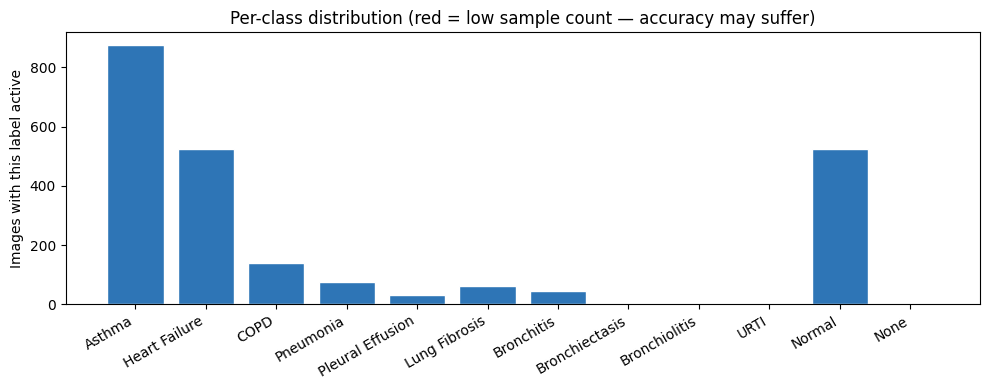

In [59]:
valid_samples = []   # List of (filepath, label_vector, matched_classes)
skipped_files = []

for fname in sorted(all_files):
    fpath = os.path.join(PNG_DIR, fname)
    label_vec, matched_classes, raw_label = parse_multilabel_vector(fname)

    if label_vec is None or len(matched_classes) == 0:
        skipped_files.append((fname, f"Could not map '{raw_label}' to any class"))
        continue

    valid_samples.append((fpath, label_vec, matched_classes))

print(f"Valid samples   : {len(valid_samples)}")
print(f"Skipped files   : {len(skipped_files)}")

if skipped_files:
    print("\nSkipped files:")
    for fname, reason in skipped_files[:10]:
        print(f"  {fname}  — {reason}")
    if len(skipped_files) > 10:
        print(f"  ... and {len(skipped_files) - 10} more")

# ── Per-class counts ──────────────────────────────────────────────────────────
# Count how many images have each class active
class_totals = torch.zeros(NUM_CLASSES)
multi_label_count = 0

for _, vec, classes in valid_samples:
    class_totals += vec
    if vec.sum() > 1:
        multi_label_count += 1

print(f"\nCompound/multi-label samples: {multi_label_count}")
print(f"\nPer-class positive sample counts:")
for i, cls in enumerate(CLASSES):
    count = int(class_totals[i].item())
    bar = "█" * count
    flag = "  ← LOW" if 0 < count < 15 else ""
    print(f"  {cls:<20}: {count:>4}  {bar}{flag}")

# Plot
plt.figure(figsize=(10, 4))
counts_list = [int(class_totals[i].item()) for i in range(NUM_CLASSES)]
colors = ['#C0392B' if c < 15 else '#2E75B6' for c in counts_list]
plt.bar(CLASSES, counts_list, color=colors, edgecolor='white')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Images with this label active")
plt.title("Per-class distribution (red = low sample count — accuracy may suffer)")
plt.tight_layout()
plt.show()

In [60]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MultiLabelSpectrogramDataset(Dataset):
    """
    Returns (image_tensor, metadata_tensor, label_vector) per sample.
      image_tensor : (3, 224, 224)  float32
      metadata     : (2,)           float32  [age_norm, gender]
      label_vector : (NUM_CLASSES,) float32  binary 0/1 per disease
    """
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fpath, label_vec, _ = self.samples[idx]
        img = Image.open(fpath).convert('RGB')
        if self.transform:
            img = self.transform(img)
        age_norm, gender = parse_age_gender(os.path.basename(fpath))
        metadata = torch.tensor([age_norm, gender], dtype=torch.float32)
        return img, metadata, label_vec

In [61]:
import random
random.seed(42)
random.shuffle(valid_samples)

n         = len(valid_samples)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_samples = valid_samples[:train_end]
val_samples   = valid_samples[train_end:val_end]
test_samples  = valid_samples[val_end:]

train_dataset = MultiLabelSpectrogramDataset(train_samples, transform=train_transforms)
val_dataset   = MultiLabelSpectrogramDataset(val_samples,   transform=val_transforms)
test_dataset  = MultiLabelSpectrogramDataset(test_samples,  transform=val_transforms)

print(f"Train samples : {len(train_samples)}")
print(f"Val samples   : {len(val_samples)}")
print(f"Test samples  : {len(test_samples)}")

# Count positives per class in training set
train_label_matrix = torch.stack([s[1] for s in train_samples])  # (N_train, 9)
pos_counts = train_label_matrix.sum(dim=0)                        # (9,) — positives per class
neg_counts = len(train_samples) - pos_counts                      # (9,) — negatives per class

# Avoid division by zero for classes with 0 positives
pos_counts_safe = pos_counts.clamp(min=1)
pos_weight = neg_counts / pos_counts_safe
pos_weight = pos_weight.to(device)

print("Positive weights per class (higher = rarer in training set):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:<20}: pos={int(pos_counts[i]):>4}  neg={int(neg_counts[i]):>4}  "
          f"pos_weight={pos_weight[i]:.2f}")

Train samples : 1593
Val samples   : 341
Test samples  : 342
Positive weights per class (higher = rarer in training set):
  Asthma              : pos= 615  neg= 978  pos_weight=1.59
  Heart Failure       : pos= 348  neg=1245  pos_weight=3.58
  COPD                : pos=  99  neg=1494  pos_weight=15.09
  Pneumonia           : pos=  60  neg=1533  pos_weight=25.55
  Pleural Effusion    : pos=  22  neg=1571  pos_weight=71.41
  Lung Fibrosis       : pos=  45  neg=1548  pos_weight=34.40
  Bronchitis          : pos=  35  neg=1558  pos_weight=44.51
  Bronchiectasis      : pos=   0  neg=1593  pos_weight=1593.00
  Bronchiolitis       : pos=   0  neg=1593  pos_weight=1593.00
  URTI                : pos=   0  neg=1593  pos_weight=1593.00
  Normal              : pos= 369  neg=1224  pos_weight=3.32
  None                : pos=   0  neg=1593  pos_weight=1593.00


In [62]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

# Confirm shapes
imgs_b, meta_b, labels_b = next(iter(train_loader))
print(f"Batch image shape    : {imgs_b.shape}")    # [32, 3, 224, 224]
print(f"Batch metadata shape : {meta_b.shape}")    # [32, 2]
print(f"Batch label shape    : {labels_b.shape}")  # [32, NUM_CLASSES]
print(f"Batch label dtype    : {labels_b.dtype}")  # torch.float32

Batch image shape    : torch.Size([32, 3, 224, 224])
Batch metadata shape : torch.Size([32, 2])
Batch label shape    : torch.Size([32, 12])
Batch label dtype    : torch.float32


In [63]:
# Create model
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features   # 1280

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features, NUM_CLASSES)   # 1280 → 9 raw logits
    # NO sigmoid here — BCEWithLogitsLoss applies it internally
    # for numerical stability
)

model = model.to(device)

# Verify output shape
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    out = model(dummy)
    print(f"Output shape: {out.shape}")   # [1, 9]
    print(f"Output (raw logits): {out[0].cpu().numpy().round(2)}")
    # These are unbounded — sigmoid will convert to (0,1) per class

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

class MetadataWeightNet(nn.Module):
    def __init__(self, meta_dim=2, num_classes=NUM_CLASSES):
        super().__init__()
        self.importance = nn.Sequential(
            nn.Linear(meta_dim, 16),
            nn.ReLU(),
            nn.Linear(16, meta_dim),
            nn.Softmax(dim=-1),         # → importance weight per feature (sums to 1)
        )
        self.projection = nn.Linear(meta_dim, num_classes)   # → logit offset

    def forward(self, metadata):
        """
        metadata : (B, 2)  — [age_norm, gender]
        returns  : (B, NUM_CLASSES)  — additive logit offset for each disease
        """
        weights          = self.importance(metadata)    # (B, 2)  importance scores
        self.last_weights = weights                     # saved for inspection after training
        weighted         = metadata * weights           # (B, 2)  scale each feature
        return self.projection(weighted)                # (B, NUM_CLASSES)

meta_model = MetadataWeightNet().to(device)

# Print a quick summary
print(f"MetadataWeightNet params: {sum(p.numel() for p in meta_model.parameters())}")

Output shape: torch.Size([1, 12])
Output (raw logits): [ 0.17  0.28 -0.01 -0.13  0.05  0.03  0.11 -0.02 -0.12  0.1  -0.13 -0.02]
Total params    : 4,022,920
Trainable params: 4,022,920
MetadataWeightNet params: 118


In [64]:
# BCEWithLogitsLoss for multi-label classification
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Internally applies sigmoid per class, then computes binary cross-entropy
# Expects: logits of shape (B, 9) and targets of shape (B, 9) with 0.0/1.0 values

optimizer = optim.AdamW(
    list(filter(lambda p: p.requires_grad, model.parameters())) +
    list(meta_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def run_epoch(loader, is_train):
    """
    One full pass over the dataset.
    Returns: (avg_loss, exact_match_accuracy, all_preds, all_targets)
    """
    model.train()      if is_train else model.eval()
    meta_model.train() if is_train else meta_model.eval()

    total_loss    = 0.0
    exact_correct = 0
    total         = 0
    all_preds_list, all_targets_list = [], []

    for imgs, metadata, label_vecs in loader:       # ← 3-tuple now
        imgs       = imgs.to(device)
        metadata   = metadata.to(device)            # (B, 2)
        label_vecs = label_vecs.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            cnn_logits   = model(imgs)              # (B, NUM_CLASSES) from EfficientNet
            meta_offset  = meta_model(metadata)     # (B, NUM_CLASSES) from MetadataWeightNet
            logits       = cnn_logits + meta_offset  # fused prediction
            loss         = criterion(logits, label_vecs)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss    += loss.item() * imgs.size(0)
        preds          = (torch.sigmoid(logits) >= THRESHOLD).float()
        exact_correct += (preds == label_vecs).all(dim=1).sum().item()
        total         += imgs.size(0)

        all_preds_list.append(preds.cpu())
        all_targets_list.append(label_vecs.cpu())

    all_preds   = torch.cat(all_preds_list,   dim=0)
    all_targets = torch.cat(all_targets_list, dim=0)

    return total_loss / total, exact_correct / total, all_preds, all_targets

In [65]:
# Training Loop
NUM_EPOCHS     = 30
SAVE_PATH      = "/content/efficientnet_pulmoscan_multilabel.pth"
SAVE_PATH_META = "/content/metadata_weight_net.pth"

THRESHOLD = 0.5

best_val_loss = float('inf')
history = {"train_loss": [], "val_loss": [], "val_exact_acc": []}

print(f"Starting training — {NUM_EPOCHS} epochs")
print(f"Saving best model to: {SAVE_PATH}")
print(f"Threshold for positive prediction: sigmoid > {THRESHOLD}")
print("-" * 70)
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<12} {'Exact Match':<14} {'Status'}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, _, _, _               = run_epoch(train_loader, is_train=True)
    val_loss, val_exact, val_p, val_t = run_epoch(val_loader,   is_train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_exact_acc"].append(val_exact)

    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), SAVE_PATH)
        torch.save(meta_model.state_dict(), SAVE_PATH_META)
        status = "saved"

    print(f"{epoch:<8} {train_loss:<14.4f} {val_loss:<12.4f} "
          f"{val_exact*100:<14.1f}% {status}")

print("-" * 70)
print(f"Training complete. Best val loss: {best_val_loss:.4f}")

# Learned metadata importance
print("\n" + "=" * 60)
print("LEARNED METADATA IMPORTANCE (averaged over val set)")
print("=" * 60)
meta_model.eval()
all_weights = []
with torch.no_grad():
    for _, metadata, _ in val_loader:
        metadata = metadata.to(device)
        meta_model(metadata)
        all_weights.append(meta_model.last_weights.cpu())
avg = torch.cat(all_weights, dim=0).mean(dim=0)
print(f"  Age importance   : {avg[0].item()*100:.1f}%")
print(f"  Gender importance: {avg[1].item()*100:.1f}%")
print("  (softmax — both sum to 100%)")

Starting training — 30 epochs
Saving best model to: /content/efficientnet_pulmoscan_multilabel.pth
Threshold for positive prediction: sigmoid > 0.5
----------------------------------------------------------------------
Epoch    Train Loss     Val Loss     Exact Match    Status
----------------------------------------------------------------------
1        0.9695         0.7971       1.8           % saved
2        0.7802         0.6830       1.8           % saved
3        0.6623         0.6180       1.8           % saved
4        0.5977         0.5584       3.8           % saved
5        0.5266         0.5298       6.2           % saved
6        0.4731         0.4800       11.4          % saved
7        0.4455         0.4596       18.2          % saved
8        0.3883         0.4290       18.5          % saved
9        0.3605         0.3690       28.7          % saved
10       0.3200         0.3735       29.9          % 
11       0.2970         0.3459       33.4          % saved
12     

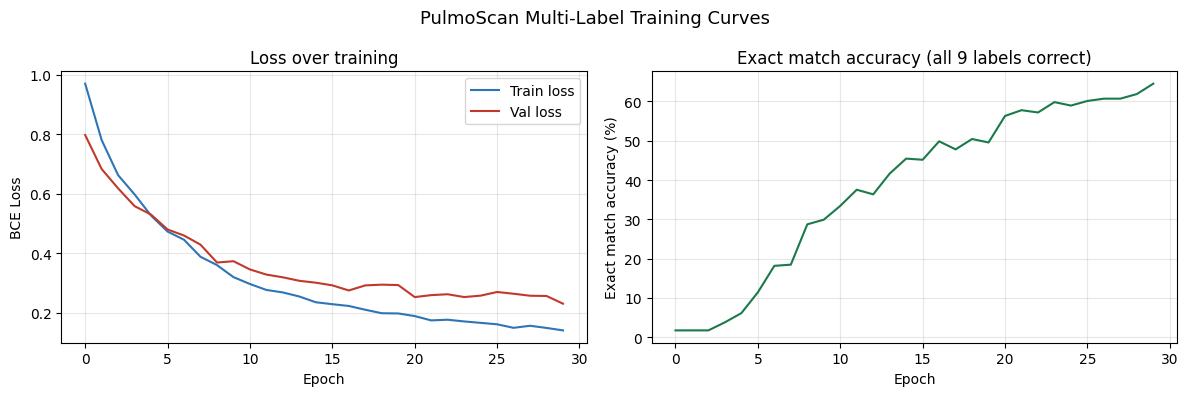

In [66]:
# Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train loss", color="#2E75B6")
axes[0].plot(history["val_loss"],   label="Val loss",   color="#C0392B")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Loss over training")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot([a * 100 for a in history["val_exact_acc"]], color="#1A7A4A")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Exact match accuracy (%)")
axes[1].set_title("Exact match accuracy (all 9 labels correct)")
axes[1].grid(alpha=0.3)

plt.suptitle("PulmoScan Multi-Label Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

Per-class performance on validation set:
----------------------------------------------------------------------
                  precision    recall  f1-score   support

          Asthma       0.81      0.81      0.81       130
   Heart Failure       0.79      0.76      0.78        93
            COPD       0.48      0.87      0.62        23
       Pneumonia       0.62      0.80      0.70        10
Pleural Effusion       0.50      1.00      0.67         3
   Lung Fibrosis       0.40      0.75      0.52         8
      Bronchitis       0.67      1.00      0.80         6
  Bronchiectasis       0.00      0.00      0.00         0
   Bronchiolitis       0.00      0.00      0.00         0
            URTI       0.00      0.00      0.00         0
          Normal       0.58      0.94      0.72        68
            None       0.00      0.00      0.00         0

       micro avg       0.68      0.83      0.75       341
       macro avg       0.40      0.58      0.47       341
    weighted avg

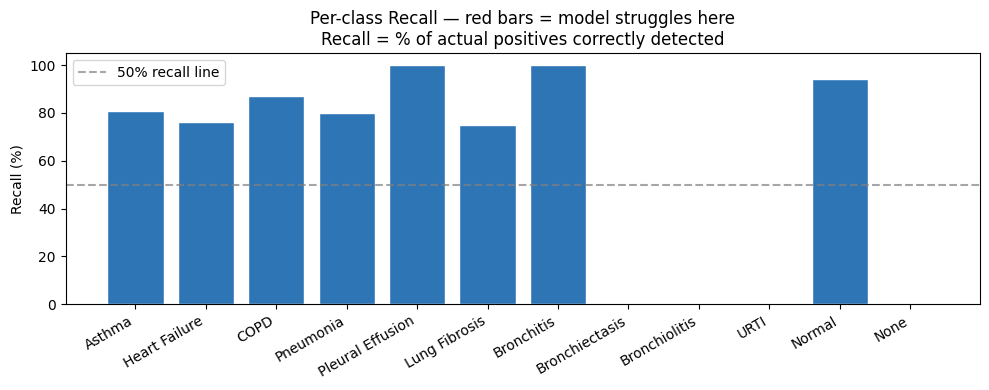

In [67]:
# Evaluation
# Reload best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
meta_model.load_state_dict(torch.load(SAVE_PATH_META, map_location=device))
_, _, all_preds, all_targets = run_epoch(val_loader, is_train=False)

# Per-class report
print("Per-class performance on validation set:")
print("-" * 70)
all_preds_np   = all_preds.numpy().astype(int)
all_targets_np = all_targets.numpy().astype(int)

print(classification_report(
    all_targets_np,
    all_preds_np,
    target_names=CLASSES,
    zero_division=0
))

# ── Per-class recall bar chart ────────────────────────────────────────────────
from sklearn.metrics import recall_score
per_class_recall = recall_score(all_targets_np, all_preds_np, average=None, zero_division=0)

plt.figure(figsize=(10, 4))
bar_colors = ['#C0392B' if r < 0.5 else '#2E75B6' for r in per_class_recall]
plt.bar(CLASSES, per_class_recall * 100, color=bar_colors, edgecolor='white')
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.7, label='50% recall line')
plt.xticks(rotation=30, ha='right')
plt.ylabel("Recall (%)")
plt.title("Per-class Recall — red bars = model struggles here\n"
          "Recall = % of actual positives correctly detected")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
#Inference
INFERENCE_THRESHOLD = 0.5

def predict_single_png(image_path, age, gender_str, threshold=INFERENCE_THRESHOLD):
    """
    Run inference on one PNG.
      image_path : path to any spectrogram PNG (filename ignored)
      age        : integer, e.g. 54
      gender_str : 'M' or 'F'

    Returns list of (disease, confidence_pct) sorted highest first.
    """
    model.eval()
    meta_model.eval()

    img    = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img).unsqueeze(0).to(device)

    age_norm = age / 100.0
    gender   = 1.0 if gender_str.upper() == 'M' else 0.0
    metadata = torch.tensor([[age_norm, gender]], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(tensor) + meta_model(metadata)
        probs  = torch.sigmoid(logits).squeeze(0)

    return sorted(
        [(CLASSES[i], round(probs[i].item() * 100, 1)) for i in range(NUM_CLASSES)],
        key=lambda x: -x[1]
    )


def print_prediction(scores, threshold=INFERENCE_THRESHOLD):
    print(f"\n{'Disease':<22} {'Confidence':>10}   Bar")
    print("-" * 65)
    for cls, pct in scores:
        bar    = "█" * int(pct / 2.5)
        flag   = "  <- PREDICTED" if pct >= threshold * 100 else ""
        print(f"  {cls:<20}: {pct:>6.1f}%   {bar}{flag}")
    predicted = [cls for cls, pct in scores if pct >= threshold * 100]
    print(f"\nPredicted: {predicted if predicted else ['None above threshold']}")
    print("Note: scores are independent and do not sum to 100%")


# ── Manual inference cell — run this on its own whenever you want to test ─────
from google.colab import files as colab_files

patient_age    = 45        # <-- change this
patient_gender = 'M'       # <-- change this: 'M' or 'F'

print(f"Upload a spectrogram PNG (filename doesn't matter).")
uploaded_inf = colab_files.upload()

for fname, data in uploaded_inf.items():
    tmp = f"/content/inf_tmp.png"
    with open(tmp, 'wb') as f:
        f.write(data)
    print(f"\nPrediction for: {fname}  |  age={patient_age}, gender={patient_gender}")
    scores = predict_single_png(tmp, age=patient_age, gender_str=patient_gender)
    print_prediction(scores)

Upload a spectrogram PNG (filename doesn't matter).


Saving EP8_70_M_Plueral_Effusion_timestretch.png to EP8_70_M_Plueral_Effusion_timestretch (5).png

Prediction for: EP8_70_M_Plueral_Effusion_timestretch (5).png  |  age=45, gender=M

Disease                Confidence   Bar
-----------------------------------------------------------------
  Pleural Effusion    :   99.7%   ███████████████████████████████████████  <- PREDICTED
  Bronchitis          :   33.8%   █████████████
  Asthma              :   10.6%   ████
  Heart Failure       :    4.5%   █
  Normal              :    4.5%   █
  Pneumonia           :    0.6%   
  COPD                :    0.0%   
  Lung Fibrosis       :    0.0%   
  Bronchiectasis      :    0.0%   
  Bronchiolitis       :    0.0%   
  URTI                :    0.0%   
  None                :    0.0%   

Predicted: ['Pleural Effusion']
Note: scores are independent and do not sum to 100%


In [74]:
# Model Summary
from torchinfo import summary

print("EfficientNet-B0 — PulmoScan Multi-Label (9 classes)")
print("=" * 60)
summary(
    model,
    input_size=(1, 3, 224, 224),
    device=device,
    col_names=["output_size", "num_params", "trainable"],
    depth=2
)

EfficientNet-B0 — PulmoScan Multi-Label (9 classes)


Layer (type:depth-idx)                                  Output Shape              Param #                   Trainable
EfficientNet                                            [1, 12]                   --                        True
├─Sequential: 1-1                                       [1, 1280, 7, 7]           --                        True
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         928                       True
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         1,448                     True
│    └─Sequential: 2-3                                  [1, 24, 56, 56]           16,714                    True
│    └─Sequential: 2-4                                  [1, 40, 28, 28]           46,640                    True
│    └─Sequential: 2-5                                  [1, 80, 14, 14]           242,930                   True
│    └─Sequential: 2-6                                  [1, 112, 14, 14]          543,148  

In [75]:
# Download weights
from google.colab import files as colab_files

download = input("Download model weights? (y/n): ").strip().lower()
if download == 'y':
    colab_files.download(SAVE_PATH)
    colab_files.download(SAVE_PATH_META)
    print("Download triggered for both weight files.")
else:
    print("Skipped. Files are still available at:")
    print(f"  {SAVE_PATH}")
    print(f"  {SAVE_PATH_META}")

Download model weights? (y/n): y


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered for both weight files.
